# Building RAG Using Open Source LLM: dari Kode ke Service

Notebook ini menjalankan RAG service untuk customer service fiktif "Emerald" secara end-to-end di Colab:

- **PostgreSQL + pgvector** sebagai knowledge base dan penyimpan riwayat chat
- **FastAPI** untuk endpoint ingestion, chat, cache, dan feedback
- **Llama 3.1 8B** (fine-tune bahasa Indonesia, GGUF) + **nomic-embed-text-v1.5** via llama-cpp-python di GPU
- **bge-reranker-v2-m3** (cross-encoder multilingual) untuk mengurutkan ulang kandidat dan menentukan relevan atau tidak

Kode aplikasinya ditulis ke file (`config.py`, `init_db.py`, `app.py`, `st_app.py`) dengan `%%writefile`, jadi file yang sama bisa langsung dipakai di luar Colab. Di dalam notebook, API diuji dengan `TestClient` FastAPI, tanpa perlu menjalankan server terpisah.

**Perbaikan utama dibanding versi awal:**
- Nama database diambil dari satu konfigurasi (versi awal memakai nama berbeda di `init_db.py` dan `app.py`)
- `ChatRequest` tidak lagi merujuk field `input_data` yang tidak ada (penyebab error di setiap request `/chat`)
- Raw completion format Alpaca, `n_ctx=4096`, prefix nomic, cosine distance + index HNSW
- Retrieval dua tahap: 10 kandidat dari pgvector, lalu diurutkan ulang oleh reranker, dan threshold diterapkan pada skor reranker
- Cache dihapus saat jawaban di-dislike atau di-regenerate, sehingga feedback benar-benar mengubah jawaban berikutnya
- Endpoint `def` biasa (bukan `async def`) dan lock untuk model, supaya inferensi tidak memblokir event loop
- `/add_knowledge` dilindungi API key (header `X-API-Key`), supaya tidak sembarang orang bisa menambah dokumen ke knowledge base
- `/chat` memakai temperature 0 (deterministik), `/regenerate` memakai temperature 0.7 (bervariasi), dan jawaban penolakan tidak pernah di-cache

## 1. Install Dependencies

llama-cpp-python di-build dengan CUDA (bisa 10–20 menit). Pastikan runtime sudah GPU.

`torch` dan `sentence-transformers` (untuk reranker) **sengaja tidak diinstal**, karena sudah tersedia di Colab. Menginstal ulang paket yang bergantung pada torch bisa menarik versi torch yang tidak cocok dengan CUDA Colab dan merusak import torch.

Setelah sel install selesai, **restart session** (Runtime → Restart session) sebelum lanjut, supaya proses Python mulai bersih. Build llama-cpp-python tetap tersimpan di disk, jadi tidak perlu diinstal ulang.

In [1]:
!CMAKE_ARGS="-DGGML_CUDA=on" pip install -q llama-cpp-python --no-cache-dir
!pip install -q psycopg2-binary fastapi httpx python-multipart pypdf

In [2]:
# torch diimport LEBIH DULU daripada llama_cpp. llama-cpp-python build CUDA bisa memuat library
# NCCL milik sistem yang lebih lama. Kalau library itu termuat duluan, torch gagal mencari simbol
# NCCL yang ia butuhkan (misalnya "undefined symbol: ncclCommShrink").
import torch, sentence_transformers
print("torch", torch.__version__, "| CUDA:", torch.cuda.is_available(),
      "| sentence-transformers", sentence_transformers.__version__)
assert torch.cuda.is_available(), "torch tidak melihat GPU. Hapus runtime (Disconnect and delete runtime) lalu jalankan ulang."

import llama_cpp
gpu_ok = llama_cpp.llama_supports_gpu_offload()
print("llama-cpp-python", llama_cpp.__version__, "| GPU offload:", gpu_ok)
assert gpu_ok, "Build tanpa CUDA. Ulangi sel install dengan runtime GPU."


ggml_cuda_init: found 1 CUDA devices (Total VRAM: 40441 MiB):
  Device 0: NVIDIA A100-SXM4-40GB, compute capability 8.0, VMM: yes, VRAM: 40441 MiB


torch 2.11.0+cu128 | CUDA: True | sentence-transformers 5.7.0
llama-cpp-python 0.3.35 | GPU offload: True


## 2. PostgreSQL + pgvector di Colab

PostgreSQL diinstal langsung di runtime Colab, dan pgvector di-build dari source. Database ini hanya hidup selama runtime aktif. Password di bawah hanya untuk instance lokal ini.

In [3]:
%%bash
apt-get -qq update > /dev/null
DEBIAN_FRONTEND=noninteractive apt-get -qq install -y postgresql postgresql-server-dev-all > /dev/null
git clone -q --branch v0.8.0 https://github.com/pgvector/pgvector.git /tmp/pgvector 2> /dev/null
cd /tmp/pgvector && make -s > /dev/null && make -s install > /dev/null
service postgresql start
sudo -u postgres psql -q -c "ALTER USER postgres PASSWORD 'postgres';"
sudo -u postgres psql -c "SELECT version();" | head -3

 * Starting PostgreSQL 16 database server
   ...done.
                                                                 version                                                                  
------------------------------------------------------------------------------------------------------------------------------------------
 PostgreSQL 16.15 (Ubuntu 16.15-0ubuntu0.24.04.1) on x86_64-pc-linux-gnu, compiled by gcc (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0, 64-bit


In [4]:
import os, secrets
os.environ.update({
    "DB_NAME": "rag_emerald",
    "DB_USER": "postgres",
    "DB_PASSWORD": "postgres",
    "DB_HOST": "localhost",
    "DB_PORT": "5432",
    # Key admin dibuat acak setiap runtime, tidak ditulis di notebook
    "ADMIN_API_KEY": secrets.token_urlsafe(24),
})
ADMIN_HEADERS = {"X-API-Key": os.environ["ADMIN_API_KEY"]}
print("ADMIN_API_KEY diset (panjang", len(os.environ["ADMIN_API_KEY"]), "karakter).")

ADMIN_API_KEY diset (panjang 32 karakter).


## 3. Konfigurasi & Skema Database

Semua kredensial dibaca dari environment variable lewat satu file `config.py`, sehingga `init_db.py` dan `app.py` pasti memakai database yang sama.

Perubahan skema: index HNSW dengan `vector_cosine_ops` di `knowledge_vector`, `cached_chat.chat_history_id` dibuat unik, dan kolom `analytics.type` dibatasi ke tiga nilai yang valid.

In [5]:
%%writefile config.py
import os

DB_CONFIG = {
    "dbname": os.getenv("DB_NAME", "rag_emerald"),
    "user": os.getenv("DB_USER", "postgres"),
    "password": os.getenv("DB_PASSWORD", ""),
    "host": os.getenv("DB_HOST", "localhost"),
    "port": os.getenv("DB_PORT", "5432"),
}
EMBED_DIM = 768

Writing config.py


In [6]:
%%writefile init_db.py
import psycopg2
from psycopg2 import sql
from config import DB_CONFIG, EMBED_DIM

TABLES = f"""
CREATE EXTENSION IF NOT EXISTS vector;

CREATE TABLE IF NOT EXISTS knowledge (
    id SERIAL PRIMARY KEY,
    document_id TEXT UNIQUE NOT NULL,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
);

CREATE TABLE IF NOT EXISTS knowledge_vector (
    id SERIAL PRIMARY KEY,
    knowledge_id INT REFERENCES knowledge(id) ON DELETE CASCADE,
    chunk_text TEXT NOT NULL,
    chunk_vector VECTOR({EMBED_DIM}) NOT NULL,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
);

CREATE INDEX IF NOT EXISTS knowledge_vector_hnsw
    ON knowledge_vector USING hnsw (chunk_vector vector_cosine_ops);

CREATE TABLE IF NOT EXISTS chat_history (
    id SERIAL PRIMARY KEY,
    instruction TEXT NOT NULL,
    input_data TEXT NOT NULL DEFAULT '',
    response TEXT NOT NULL,
    input_vector VECTOR({EMBED_DIM}),
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
);

CREATE TABLE IF NOT EXISTS cached_chat (
    id SERIAL PRIMARY KEY,
    chat_history_id INT UNIQUE REFERENCES chat_history(id) ON DELETE CASCADE,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
);

CREATE TABLE IF NOT EXISTS analytics (
    id SERIAL PRIMARY KEY,
    type VARCHAR(20) NOT NULL CHECK (type IN ('like', 'dislike', 'regenerate')),
    chat_history_id INT REFERENCES chat_history(id) ON DELETE CASCADE,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
);
"""


def setup_database_and_tables():
    admin_cfg = {**DB_CONFIG, "dbname": "postgres"}
    conn = psycopg2.connect(**admin_cfg)
    conn.autocommit = True
    with conn.cursor() as cur:
        cur.execute("SELECT 1 FROM pg_database WHERE datname = %s", (DB_CONFIG["dbname"],))
        if cur.fetchone() is None:
            cur.execute(sql.SQL("CREATE DATABASE {}").format(sql.Identifier(DB_CONFIG["dbname"])))
            print(f"Database '{DB_CONFIG['dbname']}' dibuat.")
        else:
            print(f"Database '{DB_CONFIG['dbname']}' sudah ada.")
    conn.close()

    conn = psycopg2.connect(**DB_CONFIG)
    with conn, conn.cursor() as cur:
        cur.execute(TABLES)
    conn.close()
    print("Semua tabel dan index siap.")


if __name__ == "__main__":
    setup_database_and_tables()

Writing init_db.py


In [7]:
!python init_db.py

Database 'rag_emerald' dibuat.
Semua tabel dan index siap.


## 4. Aplikasi FastAPI

Endpoint yang tersedia:

| Endpoint | Fungsi |
|---|---|
| `POST /add_knowledge` | unggah TXT/PDF, di-chunk dan di-embed ke pgvector (butuh header `X-API-Key`) |
| `GET /search` | debug: skor cosine dan skor reranker untuk kalibrasi threshold |
| `POST /chat` | tanya jawab dengan cache exact-match |
| `POST /react` | like/dislike; dislike menghapus jawaban dari cache |
| `POST /regenerate` | buat jawaban baru dan ganti isi cache |
| `GET /all-reactions` | data untuk dashboard |

In [8]:
%%writefile app.py
import io
import os
import re
import secrets
import threading
from contextlib import contextmanager
from typing import List, Optional

import numpy as np
import psycopg2
from fastapi import Depends, FastAPI, File, Header, HTTPException, Query, UploadFile
from psycopg2.extras import RealDictCursor
from pydantic import BaseModel
from pypdf import PdfReader

# Urutan import penting: torch (lewat sentence_transformers) dimuat sebelum llama_cpp,
# supaya library CUDA/NCCL milik llama.cpp tidak mendahului library yang dibutuhkan torch.
from sentence_transformers import CrossEncoder
from llama_cpp import Llama

from config import DB_CONFIG

# ---------------------------------------------------------------------------
# Konfigurasi
# ---------------------------------------------------------------------------
CHUNK_WORDS = int(os.getenv("CHUNK_WORDS", "60"))
CHUNK_OVERLAP = int(os.getenv("CHUNK_OVERLAP", "15"))
RETRIEVE_K = int(os.getenv("RETRIEVE_K", "10"))  # kandidat dari pgvector
TOP_K = int(os.getenv("TOP_K", "3"))             # chunk yang masuk prompt setelah rerank
RERANK_THRESHOLD = float(os.getenv("RERANK_THRESHOLD", "0"))  # 0 = nonaktif; kalibrasi dari /search
MAX_UPLOAD_BYTES = 10 * 1024 * 1024
ADMIN_API_KEY = os.getenv("ADMIN_API_KEY", "")  # wajib diset untuk menambah knowledge

FALLBACK = "Maaf, informasi tersebut belum tersedia. Silakan hubungi customer service Emerald."
# Keputusan "relevan atau tidak" sekarang diambil reranker (RERANK_THRESHOLD), bukan LLM.
# LLM cukup menjawab dari konteks yang sudah lolos saringan.
PERSONA = "Kamu adalah customer service perusahaan bernama Emerald."
# Versi sebelumnya: persona + aturan + kalimat penolakan wajib di slot Instruction, pertanyaan di slot Input.
# Pada model 8B ini, kalimat penolakan yang ditulis persis ternyata terlalu mudah "dipilih" model,
# bahkan saat konteksnya benar. Disimpan untuk perbandingan di notebook.
STRICT_INSTRUCTION = (
    PERSONA + " Jawab pertanyaan pelanggan HANYA berdasarkan konteks yang diberikan, singkat dan sopan. "
    "Jika konteks memuat jawabannya, sebutkan angka atau detailnya persis (harga, durasi, jumlah). "
    "Jika konteks hanya menjawab sebagian pertanyaan, jawab bagian yang tersedia. "
    f'Jika konteks sama sekali tidak berhubungan dengan pertanyaan, jawab persis: "{FALLBACK}"'
)
PROMPT_STYLE = os.getenv("PROMPT_STYLE", "question_as_instruction")

CHAT_TEMPERATURE = 0.0        # /chat deterministik: pertanyaan yang sama, jawaban yang sama
REGENERATE_TEMPERATURE = 0.7  # /regenerate sengaja lebih bervariasi
ALPACA_PROMPT = """Di bawah ini adalah instruksi yang menjelaskan tugas, dipasangkan dengan masukan yang memberikan konteks lebih lanjut. Tulis tanggapan yang melengkapi permintaan dengan tepat.

### Instruction:
{}

### Input:
{}

### Response:
{}"""
STOP = ["### Instruction:", "### Input:", "### Response:", "<|eot_id|>", "<|end_of_text|>"]
# repeat_penalty mencegah model terjebak mengulang kalimat yang sama sampai max_tokens habis
GEN_KWARGS = {"max_tokens": 256, "repeat_penalty": 1.15, "stop": STOP}

# ---------------------------------------------------------------------------
# Model (objek Llama tidak thread-safe, jadi setiap model dijaga lock)
# ---------------------------------------------------------------------------
llm = Llama.from_pretrained(
    repo_id="rubythalib33/llama3_1_8b_finetuned_bahasa_indonesia",
    filename="unsloth.Q4_K_M.gguf",
    n_gpu_layers=-1,
    n_ctx=4096,
    verbose=False,
)
text_embedder = Llama.from_pretrained(
    repo_id="nomic-ai/nomic-embed-text-v1.5-GGUF",
    filename="nomic-embed-text-v1.5.Q4_K_M.gguf",
    embedding=True,
    n_gpu_layers=-1,
    verbose=False,
)
# Reranker cross-encoder multilingual: menilai pasangan (pertanyaan, chunk) secara langsung,
# sehingga skornya jauh lebih mudah dipisahkan dengan threshold dibanding cosine similarity.
reranker = CrossEncoder("BAAI/bge-reranker-v2-m3", max_length=512)

llm_lock = threading.Lock()
embed_lock = threading.Lock()
rerank_lock = threading.Lock()

app = FastAPI(title="Emerald RAG Service")


# ---------------------------------------------------------------------------
# Helper
# ---------------------------------------------------------------------------
@contextmanager
def get_cursor(dict_rows=False):
    conn = psycopg2.connect(**DB_CONFIG)
    try:
        with conn.cursor(cursor_factory=RealDictCursor if dict_rows else None) as cur:
            yield cur
        conn.commit()
    except Exception:
        conn.rollback()
        raise
    finally:
        conn.close()


def embed(text: str, kind: str) -> str:
    """Embedding nomic dengan prefix task, dinormalisasi, dikembalikan sebagai literal pgvector."""
    prefix = {"doc": "search_document: ", "query": "search_query: "}[kind]
    with embed_lock:
        vec = np.array(text_embedder.create_embedding(prefix + text)["data"][0]["embedding"], dtype=np.float32)
    vec /= np.linalg.norm(vec)
    return "[" + ",".join(f"{x:.6f}" for x in vec) + "]"


def normalize(text: str) -> str:
    return " ".join(text.lower().split())


def chunk_words(text: str, size=CHUNK_WORDS, overlap=CHUNK_OVERLAP) -> List[str]:
    if not (0 <= overlap < size):
        raise ValueError("Butuh 0 <= overlap < size")
    words, chunks = text.split(), []
    for i in range(0, len(words), size - overlap):
        chunks.append(" ".join(words[i:i + size]))
        if i + size >= len(words):
            break
    return chunks


def retrieve(query_vec: str, k: int = RETRIEVE_K):
    with get_cursor(dict_rows=True) as cur:
        cur.execute(
            """
            SELECT k.document_id, kv.chunk_text,
                   1 - (kv.chunk_vector <=> %s::vector) AS similarity
            FROM knowledge_vector kv JOIN knowledge k ON k.id = kv.knowledge_id
            ORDER BY kv.chunk_vector <=> %s::vector
            LIMIT %s
            """,
            (query_vec, query_vec, k),
        )
        return [dict(r) for r in cur.fetchall()]


def rerank(question: str, candidates: List[dict]) -> List[dict]:
    """Tambahkan rerank_score (0-1) ke setiap kandidat lalu urutkan dari yang paling relevan."""
    if not candidates:
        return []
    with rerank_lock:
        scores = np.asarray(reranker.predict([(question, c["chunk_text"]) for c in candidates]), dtype=np.float32)
    if scores.min() < 0 or scores.max() > 1:  # sebagian versi mengembalikan logit mentah
        scores = 1 / (1 + np.exp(-scores))
    for c, sc in zip(candidates, scores):
        c["rerank_score"] = float(sc)
    return sorted(candidates, key=lambda c: c["rerank_score"], reverse=True)


def is_fallback(answer: str) -> bool:
    return FALLBACK.lower()[:40] in answer.lower()


NUM_RE = re.compile(r"\d+(?:[.,]\d+)*")
SENT_SPLIT_RE = re.compile(r"(?<=[.!?])\s+")


def clean_answer(answer: str, question: str, truncated: bool = False) -> str:
    """Rapikan pola rusak yang sering muncul pada model 8B ini: jawaban diawali salinan pertanyaan,
    kalimat yang sama diulang-ulang, dan kalimat terakhir yang terpotong karena max_tokens habis."""
    text = answer.strip()
    if truncated and not text.endswith((".", "!", "?")):
        cut = max(text.rfind("."), text.rfind("!"), text.rfind("?"))
        if cut > 0:
            text = text[:cut + 1]
    q = question.strip().rstrip("?.! ")
    if q and normalize(text).startswith(normalize(q)):
        text = text[len(q):].lstrip(" ?.!:-\n")
    sentences = [s for s in SENT_SPLIT_RE.split(text) if s.strip()]
    seen, unique = set(), []
    for s in sentences:
        key = normalize(s)
        if key not in seen:
            seen.add(key)
            unique.append(s.strip())
    if len(unique) < len(sentences):  # ada kalimat berulang: pakai versi tanpa duplikat
        text = " ".join(unique)
    return text.strip()


def ungrounded_numbers(answer: str, context: str) -> List[str]:
    """Angka di jawaban yang tidak muncul di konteks. Harga, durasi, dan jumlah yang tidak ada
    di knowledge base tidak boleh disampaikan ke pelanggan."""
    ctx = set(NUM_RE.findall(context))
    ctx |= {n.replace(".", "").replace(",", "") for n in ctx}
    return [n for n in NUM_RE.findall(answer) if n not in ctx and n.replace(".", "").replace(",", "") not in ctx]


def is_unusable(answer: str, question: str) -> bool:
    """Jawaban yang tidak boleh masuk cache: penolakan, kosong, atau model hanya mengulang pertanyaan."""
    a = normalize(answer).rstrip("?.! ")
    return not a or is_fallback(answer) or a == normalize(question).rstrip("?.! ")


def build_prompt(question: str, context: str, style: Optional[str] = None) -> str:
    style = style or PROMPT_STYLE
    if style == "strict_refusal":
        return ALPACA_PROMPT.format(STRICT_INSTRUCTION, f"Konteks:\n{context}\n\nPertanyaan pelanggan:\n{question}", "")
    # Pola yang sama dengan format fine-tune Alpaca: pertanyaan sebagai instruksi, konteks sebagai input.
    instruction = (f"{PERSONA} Jawab pertanyaan pelanggan berikut secara singkat dan sopan, "
                   f"hanya berdasarkan informasi pada bagian Input.\n\nPertanyaan: {question}")
    return ALPACA_PROMPT.format(instruction, context, "")


def select_chunks(question: str, q_vec: str) -> List[dict]:
    ranked = rerank(question, retrieve(q_vec))
    return [c for c in ranked if c["rerank_score"] >= RERANK_THRESHOLD][:TOP_K]


def generate(question: str, temperature: float = CHAT_TEMPERATURE):
    """Retrieve + generate. Return (jawaban, vektor query, sumber, llm_dipanggil)."""
    q_vec = embed(question, "query")
    chunks = select_chunks(question, q_vec)
    if not chunks:
        return FALLBACK, q_vec, [], False

    context = "\n\n---\n\n".join(c["chunk_text"] for c in chunks)
    prompt = build_prompt(question, context)
    with llm_lock:
        out = llm(prompt, temperature=temperature, **GEN_KWARGS)
    choice = out["choices"][0]
    answer = clean_answer(choice["text"], question, truncated=choice.get("finish_reason") == "length")
    # Guardrail: jawaban yang memuat angka di luar konteks tidak disampaikan ke pelanggan
    if ungrounded_numbers(answer, context):
        return FALLBACK, q_vec, sorted({c["document_id"] for c in chunks}), True
    sources = sorted({c["document_id"] for c in chunks})
    return answer, q_vec, sources, True


def save_chat(instruction: str, response: str, input_vec: str) -> int:
    with get_cursor() as cur:
        cur.execute(
            "INSERT INTO chat_history (instruction, response, input_vector) VALUES (%s, %s, %s::vector) RETURNING id",
            (instruction, response, input_vec),
        )
        return cur.fetchone()[0]


def cache(chat_history_id: int):
    with get_cursor() as cur:
        cur.execute("INSERT INTO cached_chat (chat_history_id) VALUES (%s) ON CONFLICT DO NOTHING", (chat_history_id,))


def uncache(chat_history_id: int):
    with get_cursor() as cur:
        cur.execute("DELETE FROM cached_chat WHERE chat_history_id = %s", (chat_history_id,))


def chat_exists(chat_history_id: int) -> Optional[dict]:
    with get_cursor(dict_rows=True) as cur:
        cur.execute("SELECT id, instruction FROM chat_history WHERE id = %s", (chat_history_id,))
        return cur.fetchone()


def add_reaction(chat_history_id: int, reaction: str):
    with get_cursor() as cur:
        cur.execute("INSERT INTO analytics (type, chat_history_id) VALUES (%s, %s)", (reaction, chat_history_id))


# ---------------------------------------------------------------------------
# Schema request/response
# ---------------------------------------------------------------------------
class ChatRequest(BaseModel):
    instruction: str


class ChatResponse(BaseModel):
    response: str
    chat_history_id: int
    cached: bool
    sources: List[str]


class ReactionRequest(BaseModel):
    chat_history_id: int
    reaction: str


class RegenerateRequest(BaseModel):
    chat_history_id: int


# ---------------------------------------------------------------------------
# Endpoint (def biasa: FastAPI menjalankannya di threadpool, event loop tidak terblokir)
# ---------------------------------------------------------------------------
def require_admin(x_api_key: Optional[str] = Header(None)):
    """Hanya pemegang ADMIN_API_KEY yang boleh mengubah knowledge base."""
    if not ADMIN_API_KEY:
        raise HTTPException(503, "ADMIN_API_KEY belum diset di server.")
    if not x_api_key or not secrets.compare_digest(x_api_key, ADMIN_API_KEY):
        raise HTTPException(401, "API key tidak valid.")


@app.post("/add_knowledge", dependencies=[Depends(require_admin)])
def add_knowledge(document_id: str = Query(...), file: UploadFile = File(...)):
    if file.content_type not in ("text/plain", "application/pdf"):
        raise HTTPException(400, "Hanya file PDF dan TXT yang didukung.")
    content = file.file.read(MAX_UPLOAD_BYTES + 1)
    if len(content) > MAX_UPLOAD_BYTES:
        raise HTTPException(413, "Ukuran file maksimal 10 MB.")

    try:
        if file.content_type == "text/plain":
            text = content.decode("utf-8")
        else:
            reader = PdfReader(io.BytesIO(content))
            text = "\n".join(p.extract_text() or "" for p in reader.pages)
    except Exception as e:
        raise HTTPException(400, f"Gagal membaca file: {e}")

    chunks = chunk_words(text)
    if not chunks:
        raise HTTPException(400, "Tidak ada teks yang bisa diekstrak (PDF hasil scan perlu OCR).")

    vectors = [embed(c, "doc") for c in chunks]
    try:
        with get_cursor() as cur:
            cur.execute("INSERT INTO knowledge (document_id) VALUES (%s) RETURNING id", (document_id,))
            knowledge_id = cur.fetchone()[0]
            for c, v in zip(chunks, vectors):
                cur.execute(
                    "INSERT INTO knowledge_vector (knowledge_id, chunk_text, chunk_vector) VALUES (%s, %s, %s::vector)",
                    (knowledge_id, c, v),
                )
    except psycopg2.errors.UniqueViolation:
        raise HTTPException(409, f"document_id '{document_id}' sudah ada.")
    return {"message": "Knowledge berhasil ditambahkan.", "document_id": document_id, "chunks": len(chunks)}


@app.get("/search")
def search(q: str = Query(...), k: int = Query(TOP_K, ge=1, le=20)):
    """Endpoint debug: skor cosine (pgvector) dan skor reranker, untuk mengkalibrasi RERANK_THRESHOLD."""
    ranked = rerank(q, retrieve(embed(q, "query"), RETRIEVE_K))[:k]
    return {"query": q, "rerank_threshold": RERANK_THRESHOLD,
            "results": [{**r, "similarity": round(float(r["similarity"]), 4),
                         "rerank_score": round(r["rerank_score"], 4)} for r in ranked]}


@app.post("/chat", response_model=ChatResponse)
def chat(request: ChatRequest):
    question = normalize(request.instruction)
    with get_cursor(dict_rows=True) as cur:
        cur.execute(
            """
            SELECT ch.id, ch.response FROM chat_history ch
            JOIN cached_chat cc ON cc.chat_history_id = ch.id
            WHERE ch.instruction = %s
            ORDER BY cc.created_at DESC LIMIT 1
            """,
            (question,),
        )
        hit = cur.fetchone()
    if hit:
        return ChatResponse(response=hit["response"], chat_history_id=hit["id"], cached=True, sources=[])

    answer, q_vec, sources, llm_called = generate(question)
    chat_id = save_chat(question, answer, q_vec)
    # Hanya jawaban substantif yang di-cache. Jawaban penolakan (baik dari threshold maupun dari LLM)
    # tidak di-cache, supaya penolakan keliru atau knowledge baru tidak "terkunci" di cache.
    if llm_called and not is_unusable(answer, question):
        cache(chat_id)
    return ChatResponse(response=answer, chat_history_id=chat_id, cached=False, sources=sources)


@app.post("/regenerate", response_model=ChatResponse)
def regenerate(request: RegenerateRequest):
    old = chat_exists(request.chat_history_id)
    if not old:
        raise HTTPException(404, "Chat history tidak ditemukan.")
    answer, q_vec, sources, llm_called = generate(old["instruction"], temperature=REGENERATE_TEMPERATURE)
    new_id = save_chat(old["instruction"], answer, q_vec)
    add_reaction(old["id"], "regenerate")
    uncache(old["id"])
    if llm_called and not is_unusable(answer, old["instruction"]):
        cache(new_id)
    return ChatResponse(response=answer, chat_history_id=new_id, cached=False, sources=sources)


@app.post("/react")
def react(request: ReactionRequest):
    if request.reaction not in ("like", "dislike"):
        raise HTTPException(400, "Reaction harus 'like' atau 'dislike'.")
    if not chat_exists(request.chat_history_id):
        raise HTTPException(404, "Chat history tidak ditemukan.")
    add_reaction(request.chat_history_id, request.reaction)
    if request.reaction == "dislike":
        uncache(request.chat_history_id)  # jawaban yang di-dislike tidak disajikan lagi dari cache
    return {"message": "Reaction tersimpan."}


@app.get("/all-reactions")
def all_reactions(
    reaction_type: str = Query(..., pattern="^(like|dislike|regenerate)$"),
    start_datetime: Optional[str] = Query(None, description="YYYY-MM-DD HH:MM:SS"),
    end_datetime: Optional[str] = Query(None, description="YYYY-MM-DD HH:MM:SS"),
):
    query, params = "SELECT * FROM analytics WHERE type = %s", [reaction_type]
    if start_datetime:
        query += " AND created_at >= %s"
        params.append(start_datetime)
    if end_datetime:
        query += " AND created_at <= %s"
        params.append(end_datetime)
    with get_cursor(dict_rows=True) as cur:
        cur.execute(query + " ORDER BY created_at", params)
        return {"reactions": cur.fetchall()}

Writing app.py


## 5. Load Aplikasi

Import `app.py` sekaligus memuat LLM, embedder, dan reranker.

In [9]:
from fastapi.testclient import TestClient
import app as rag_service

client = TestClient(rag_service.app)
print("Service siap.")

Service siap.


## 6. Ingest Knowledge

Data FAQ Emerald (garansi, retur, pengiriman) diunggah sebagai tiga dokumen terpisah, supaya sumber jawaban bisa dilacak per dokumen. Unggahan kedua dengan `document_id` yang sama akan ditolak dengan status 409, dan unggahan tanpa API key ditolak dengan status 401.

In [10]:
FAQ_EMERALD = {
    "faq_produk": "Garansi produk kami berlaku selama 1 tahun sejak tanggal pembelian. "
                  "Klaim garansi dapat dilakukan melalui aplikasi atau toko resmi.",
    "sop_retur": "Proses retur barang maksimal 7 hari setelah barang diterima. "
                 "Barang harus dalam kondisi asli dan menyertakan bukti pembelian.",
    "faq_pengiriman": "Pengiriman reguler memakan waktu 2-4 hari kerja. "
                      "Pengiriman ekspres tersedia untuk kota-kota besar dengan estimasi 1 hari kerja.",
}

for doc_id, text in FAQ_EMERALD.items():
    r = client.post("/add_knowledge", params={"document_id": doc_id}, headers=ADMIN_HEADERS,
                    files={"file": (f"{doc_id}.txt", text.encode("utf-8"), "text/plain")})
    print(r.status_code, r.json())

# Unggah ulang: harus ditolak
r = client.post("/add_knowledge", params={"document_id": "faq_produk"}, headers=ADMIN_HEADERS,
                files={"file": ("faq_produk.txt", FAQ_EMERALD["faq_produk"].encode(), "text/plain")})
print("\nUnggah ulang:", r.status_code, r.json())

# Tanpa API key: harus ditolak
r = client.post("/add_knowledge", params={"document_id": "dokumen_liar"},
                files={"file": ("liar.txt", b"Semua produk gratis hari ini.", "text/plain")})
print("Tanpa API key:", r.status_code, r.json())


200 {'message': 'Knowledge berhasil ditambahkan.', 'document_id': 'faq_produk', 'chunks': 1}
200 {'message': 'Knowledge berhasil ditambahkan.', 'document_id': 'sop_retur', 'chunks': 1}
200 {'message': 'Knowledge berhasil ditambahkan.', 'document_id': 'faq_pengiriman', 'chunks': 1}

Unggah ulang: 409 {'detail': "document_id 'faq_produk' sudah ada."}
Tanpa API key: 401 {'detail': 'API key tidak valid.'}


### Unggah katalog PDF

Katalog Emerald (`katalog_produk_emerald.pdf`) adalah **data sintetis** untuk latihan ini, bukan bagian dari materi bootcamp. Isinya 17 produk kantor beserta harganya dan halaman Ketentuan Pembelian (pemesanan, pengiriman, retur dan cara mengajukannya, garansi, serta pembelian grosir).


In [11]:
from google.colab import files

uploaded = files.upload()
for filename, content in uploaded.items():
    r = client.post("/add_knowledge", params={"document_id": filename.rsplit(".", 1)[0]}, headers=ADMIN_HEADERS,
                    files={"file": (filename, content, "application/pdf")})
    print(filename, r.status_code, r.json())

Saving katalog_produk_emerald.pdf to katalog_produk_emerald.pdf
katalog_produk_emerald.pdf 200 {'message': 'Knowledge berhasil ditambahkan.', 'document_id': 'katalog_produk_emerald', 'chunks': 13}


## 7. Kalibrasi Threshold: Cosine vs Reranker

Pada run sebelumnya, threshold dipasang langsung pada **cosine similarity** dan ternyata tidak ada satu nilai pun yang bisa memisahkan pertanyaan relevan dari yang tidak relevan. Contohnya, "Ada tinta printer apa saja?" (relevan) mendapat 0.6503, sementara "Apa itu RAG?" (tidak relevan) justru mendapat 0.6846. Skor nomic berkumpul di rentang yang sempit, sehingga distribusi keduanya tumpang tindih.

Karena itu, retrieval sekarang dua tahap. pgvector mengambil 10 kandidat berdasarkan cosine, lalu **reranker cross-encoder** menilai setiap pasangan (pertanyaan, chunk) secara langsung dan memberi skor 0–1. Threshold dipasang pada skor reranker. Tabel di bawah menampilkan kedua skor supaya bisa dibandingkan.

In [12]:
import pandas as pd
pd.set_option("display.max_colwidth", 80)

CALIBRATION = [
    ("relevan", "Berapa lama garansi produk?"),
    ("relevan", "Bagaimana cara retur barang?"),
    ("relevan", "Berapa lama pengiriman reguler?"),
    ("relevan", "Berapa harga kertas HVS A4 80 gsm?"),
    ("relevan", "Ada tinta printer apa saja?"),
    ("relevan", "Apakah dapat diskon kalau beli 30 unit?"),
    ("tidak relevan", "Apa itu RAG dan bagaimana cara kerjanya?"),
    ("tidak relevan", "Berapa harga saham Tesla hari ini?"),
    ("tidak relevan", "halo siapa kamu"),
]

rows = []
for label, q in CALIBRATION:
    res = client.get("/search", params={"q": q, "k": 10}).json()["results"]
    rows.append({"label": label, "pertanyaan": q,
                 "top_cosine": max(r["similarity"] for r in res),
                 "top_rerank": res[0]["rerank_score"],
                 "dokumen_teratas": res[0]["document_id"]})
df_cal = pd.DataFrame(rows)
df_cal

,label,pertanyaan,top_cosine,top_rerank,dokumen_teratas
0,relevan,Berapa lama garansi produk?,0.7354,0.9809,faq_produk
1,relevan,Bagaimana cara retur barang?,0.7854,0.9831,katalog_produk_emerald
2,relevan,Berapa lama pengiriman reguler?,0.7593,0.9954,faq_pengiriman
3,relevan,Berapa harga kertas HVS A4 80 gsm?,0.7938,0.9917,katalog_produk_emerald
4,relevan,Ada tinta printer apa saja?,0.6967,0.2725,katalog_produk_emerald
5,relevan,Apakah dapat diskon kalau beli 30 unit?,0.7284,0.0229,katalog_produk_emerald
6,tidak relevan,Apa itu RAG dan bagaimana cara kerjanya?,0.7149,0.0006,katalog_produk_emerald
7,tidak relevan,Berapa harga saham Tesla hari ini?,0.6862,0.0000,katalog_produk_emerald
8,tidak relevan,halo siapa kamu,0.5928,0.0002,katalog_produk_emerald


In [13]:
for kolom in ["top_cosine", "top_rerank"]:
    rel = df_cal.loc[df_cal.label == "relevan", kolom].min()
    irr = df_cal.loc[df_cal.label == "tidak relevan", kolom].max()
    status = "terpisah" if rel > irr else "TUMPANG TINDIH"
    print(f"{kolom:<11} relevan terendah {rel:.4f} | tidak relevan tertinggi {irr:.4f} | celah {rel - irr:+.4f} ({status})")

top_cosine  relevan terendah 0.6967 | tidak relevan tertinggi 0.7149 | celah -0.0182 (TUMPANG TINDIH)
top_rerank  relevan terendah 0.0229 | tidak relevan tertinggi 0.0006 | celah +0.0223 (terpisah)


In [15]:
RERANK_THRESHOLD = 0.01  # isi dengan nilai di dalam celah top_rerank di atas
assert RERANK_THRESHOLD is not None, "Isi RERANK_THRESHOLD dulu berdasarkan kolom top_rerank."
rag_service.RERANK_THRESHOLD = RERANK_THRESHOLD
print("RERANK_THRESHOLD =", rag_service.RERANK_THRESHOLD)

RERANK_THRESHOLD = 0.01


### Diagnostik: retrieval sudah benar, kenapa LLM menolak?

Pada run sebelumnya, pertanyaan harga kertas HVS mendapat chunk katalog yang tepat (skor reranker 0.99), tapi model tetap menjawab dengan kalimat penolakan. Artinya masalahnya ada di tahap **generation**, bukan retrieval.

Sel di bawah memperlihatkan konteks yang benar-benar dikirim ke LLM, lalu membandingkan dua gaya prompt pada konteks yang sama:
- `strict_refusal`: gaya sebelumnya, dengan aturan dan kalimat penolakan wajib di slot Instruction.
- `question_as_instruction`: pertanyaan di slot Instruction dan konteks di slot Input, tanpa kalimat penolakan. Keputusan menolak sudah diambil reranker.

In [16]:
DIAG_QUESTIONS = [
    "Berapa lama garansi produk?",
    "Bagaimana cara retur barang?",
    "Berapa harga kertas HVS A4 80 gsm?",
    "Apakah dapat diskon kalau beli 30 unit?",
]

rows = []
for q in DIAG_QUESTIONS:
    q_norm = rag_service.normalize(q)
    chunks = rag_service.select_chunks(q_norm, rag_service.embed(q_norm, "query"))
    print("=" * 80)
    print("Q:", q)
    for c in chunks:
        print(f"  [rerank {c['rerank_score']:.4f}] {c['document_id']}: {c['chunk_text'][:110]}...")
    context = "\n\n---\n\n".join(c["chunk_text"] for c in chunks)
    for style in ["strict_refusal", "question_as_instruction"]:
        prompt = rag_service.build_prompt(q_norm, context, style=style)
        out = rag_service.llm(prompt, temperature=0.0, **rag_service.GEN_KWARGS)
        ans = out["choices"][0]["text"].strip()
        print(f"  -> {style}: {ans}")
        rows.append({"pertanyaan": q, "gaya_prompt": style, "menolak": rag_service.is_fallback(ans), "jawaban": ans})

df_diag = pd.DataFrame(rows)
df_diag.pivot(index="pertanyaan", columns="gaya_prompt", values="menolak")

Q: Berapa lama garansi produk?
  [rerank 0.9825] faq_produk: Garansi produk kami berlaku selama 1 tahun sejak tanggal pembelian. Klaim garansi dapat dilakukan melalui apli...
  [rerank 0.8704] katalog_produk_emerald: barang ditukar dalam 3-5 hari kerja. Garansi Produk elektronik kantor bergaransi 1 tahun sejak tanggal pembeli...
  [rerank 0.5728] katalog_produk_emerald: resmi Emerald. Kedua, pilih barang yang ingin diretur, tulis alasan retur, lalu unggah foto barang dan bukti p...
  -> strict_refusal: Maaf, informasi tersebut belum tersedia. Silakan hubungi customer service Emerald.
  -> question_as_instruction: Garansi produk kami berlaku selama 1 tahun sejak tanggal pembelian. Klaim garansi dapat dilakukan melalui aplikasi atau toko resmi.
Q: Bagaimana cara retur barang?
  [rerank 0.9836] katalog_produk_emerald: pembelian di atas Rp500.000. Retur Proses retur barang maksimal 7 hari setelah barang diterima. Barang harus d...
  [rerank 0.9263] sop_retur: Proses retur barang maksimal 7

gaya_prompt,question_as_instruction,strict_refusal
pertanyaan,,
Apakah dapat diskon kalau beli 30 unit?,False,True
Bagaimana cara retur barang?,False,False
Berapa harga kertas HVS A4 80 gsm?,False,True
Berapa lama garansi produk?,False,True


## 8. Chat

Setiap jawaban dari LLM melewati dua pemeriksaan sebelum dikirim:
- **Pembersihan.** Salinan pertanyaan di awal jawaban, kalimat yang berulang, dan kalimat terakhir yang terpotong dibuang.
- **Pemeriksaan angka.** Kalau jawaban memuat angka (harga, durasi, jumlah) yang tidak ada di konteks, jawaban diganti dengan kalimat penolakan dan tidak di-cache. Untuk customer service, lebih aman tidak menjawab daripada menyebut angka yang salah.


In [17]:
import time

def tanya(q):
    t0 = time.perf_counter()
    r = client.post("/chat", json={"instruction": q}).json()
    print(f"Q: {q}")
    print(f"A: {r['response']}")
    print(f"   id={r['chat_history_id']} | cached={r['cached']} | sumber={r['sources']} | {time.perf_counter()-t0:.2f}s\n")
    return r

r_garansi = tanya("Berapa lama garansi produk?")
_ = tanya("Bagaimana cara retur barang?")
_ = tanya("Apa itu RAG dan bagaimana cara kerjanya?")
_ = tanya("Berapa harga saham Tesla hari ini?")
_ = tanya("Berapa harga kertas HVS A4 80 gsm?")
_ = tanya("Ada tinta printer apa saja?")
_ = tanya("Apakah dapat diskon kalau beli 30 unit?")

Q: Berapa lama garansi produk?
A: Garansi produk kami berlaku selama 1 tahun sejak tanggal pembelian. Klaim garansi dapat dilakukan melalui aplikasi atau toko resmi.
   id=1 | cached=False | sumber=['faq_produk', 'katalog_produk_emerald'] | 0.60s

Q: Bagaimana cara retur barang?
A: Proses retun barang maksimal 7 hari setelah barang diterima. Barang harus dalam kondisi asli dan menyertakan bukti pembelian. Cara mengajukan retur: pertama, buka menu Pesanan di aplikasi Emerald lalu pilih Ajukan Retur, atau datang langsung ke toko resmi Emerald. Kedua, pilih barang yang ingin diretur, tulis alasan retur, lalu unggah foto barang dan bukti pembelian. Ketiga, kemas barang dalam kondisi asli dan kirim melalui kurir yang ditunjuk aplikasi, atau serahkan langsung ke toko. Keempat, setelah barang diterima dan diperiksa, dana dikembalikan atau barang ditukar dalam 3-5 hari kerja. Garansi Produk elektronik kantor bergaransi 1 tahun sejak tanggal pembelian.
   id=2 | cached=False | sumber=['katalog_

### Coba Tebak Dulu
Pertanyaan garansi ditanyakan lagi dengan huruf besar dan spasi berbeda. Apakah jawabannya datang dari cache? (Pertanyaan dinormalisasi dulu sebelum dicocokkan.)

In [18]:
_ = tanya("berapa lama   GARANSI produk?")


Q: berapa lama   GARANSI produk?
A: Garansi produk kami berlaku selama 1 tahun sejak tanggal pembelian. Klaim garansi dapat dilakukan melalui aplikasi atau toko resmi.
   id=1 | cached=True | sumber=[] | 0.02s



## 9. Feedback Loop: Dislike dan Regenerate

Di versi awal, jawaban yang di-dislike tetap tersimpan di cache, jadi pertanyaan yang sama terus mendapat jawaban yang sama. Sekarang dislike menghapus jawaban dari cache, dan regenerate (temperature 0.7) membuat jawaban baru yang menggantikan isi cache. Jawaban penolakan tidak di-cache, supaya penolakan yang keliru tidak ikut "terkunci".

In [19]:
cid = r_garansi["chat_history_id"]
print(client.post("/react", json={"chat_history_id": cid, "reaction": "dislike"}).json())

r_baru = tanya("Berapa lama garansi produk?")        # cached=False: dibuat ulang
r_regen = client.post("/regenerate", json={"chat_history_id": r_baru["chat_history_id"]}).json()
print("Regenerate:", r_regen, "\n")
_ = tanya("Berapa lama garansi produk?")             # cached=True: jawaban hasil regenerate

_ = client.post("/react", json={"chat_history_id": r_regen["chat_history_id"], "reaction": "like"})
print("Reaction untuk id yang tidak ada:",
      client.post("/react", json={"chat_history_id": 99999, "reaction": "like"}).status_code)

{'message': 'Reaction tersimpan.'}
Q: Berapa lama garansi produk?
A: Garansi produk kami berlaku selama 1 tahun sejak tanggal pembelian. Klaim garansi dapat dilakukan melalui aplikasi atau toko resmi.
   id=8 | cached=False | sumber=['faq_produk', 'katalog_produk_emerald'] | 0.57s

Regenerate: {'response': 'Garansi produk kami berlaku selama 1 tahun sejak tanggal pembelian. Klaim garansi dapat dilakukan melalui aplikasi atau toko resmi.', 'chat_history_id': 9, 'cached': False, 'sources': ['faq_produk', 'katalog_produk_emerald']} 

Q: Berapa lama garansi produk?
A: Garansi produk kami berlaku selama 1 tahun sejak tanggal pembelian. Klaim garansi dapat dilakukan melalui aplikasi atau toko resmi.
   id=9 | cached=True | sumber=[] | 0.02s

Reaction untuk id yang tidak ada: 404


## 10. Dashboard Reaksi

Versi Streamlit ada di `st_app.py` (Tahap 11). Di notebook, data yang sama divisualisasikan dengan matplotlib. Hari tanpa reaksi diisi 0, supaya grafik tidak menarik garis melintasi hari kosong.

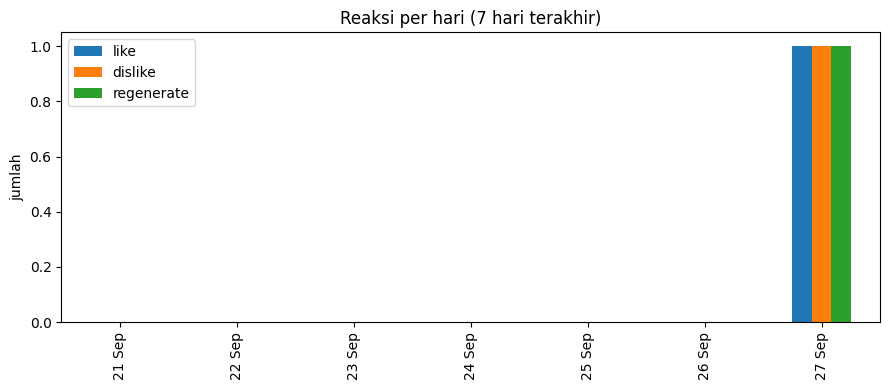

,21 Sep,22 Sep,23 Sep,24 Sep,25 Sep,26 Sep,27 Sep
like,0,0,0,0,0,0,1
dislike,0,0,0,0,0,0,1
regenerate,0,0,0,0,0,0,1


In [20]:
import matplotlib.pyplot as plt

end = pd.Timestamp.now().normalize()
start = end - pd.Timedelta(days=6)
counts = {}
for t in ["like", "dislike", "regenerate"]:
    data = client.get("/all-reactions", params={"reaction_type": t}).json()["reactions"]
    s = pd.to_datetime(pd.Series([d["created_at"] for d in data], dtype="object")).dt.normalize().value_counts()
    counts[t] = s.reindex(pd.date_range(start, end), fill_value=0)

df_counts = pd.DataFrame(counts)
df_counts.index = df_counts.index.strftime("%d %b")
df_counts.plot(kind="bar", figsize=(9, 4), title="Reaksi per hari (7 hari terakhir)")
plt.ylabel("jumlah")
plt.tight_layout()
plt.show()
df_counts.T

## 11. Dashboard Streamlit & Menjalankan di Luar Colab

Untuk menjalankan service secara lokal (butuh PostgreSQL + pgvector):

```bash
pip install -r requirements.txt
export DB_PASSWORD=...        # dan variabel DB_* lain bila perlu
python init_db.py
uvicorn app:app --port 8000
streamlit run st_app.py       # di terminal lain
```

In [21]:
%%writefile st_app.py
import os
from datetime import datetime, timedelta

import pandas as pd
import requests
import streamlit as st

API_URL = os.getenv("API_URL", "http://localhost:8000")

st.title("Reaction Monitoring Dashboard")

reaction_type = st.selectbox("Pilih tipe reaksi:", ["like", "dislike", "regenerate"], index=1)
start_date = st.date_input("Tanggal mulai:", value=(datetime.now() - timedelta(days=30)).date())
end_date = st.date_input("Tanggal akhir:", value=datetime.now().date())
plot_type = st.selectbox("Jenis grafik:", ["Bar", "Line"])

if start_date > end_date:
    st.error("Tanggal akhir harus setelah tanggal mulai.")
    st.stop()


def fetch_reactions(reaction_type, start, end):
    params = {
        "reaction_type": reaction_type,
        "start_datetime": datetime.combine(start, datetime.min.time()).strftime("%Y-%m-%d %H:%M:%S"),
        "end_datetime": datetime.combine(end, datetime.max.time()).strftime("%Y-%m-%d %H:%M:%S"),
    }
    try:
        resp = requests.get(f"{API_URL}/all-reactions", params=params, timeout=10)
        resp.raise_for_status()
        return resp.json()["reactions"]
    except requests.RequestException as e:
        st.error(f"Gagal mengambil data dari API: {e}")
        return None


reactions = fetch_reactions(reaction_type, start_date, end_date)

if reactions:
    df = pd.DataFrame(reactions)
    df["created_at"] = pd.to_datetime(df["created_at"])
    daily = df.groupby(df["created_at"].dt.normalize()).size()
    # Hari tanpa reaksi diisi 0, supaya grafik tidak menarik garis melintasi hari kosong
    full_range = pd.date_range(start_date, end_date, freq="D")
    daily = daily.reindex(full_range, fill_value=0).rename("jumlah")
    st.metric(f"Total {reaction_type}", int(daily.sum()))
    (st.bar_chart if plot_type == "Bar" else st.line_chart)(daily)
elif reactions is not None:
    st.warning("Tidak ada reaksi pada rentang tanggal ini.")

Writing st_app.py


In [22]:
%%writefile requirements.txt
llama-cpp-python
fastapi
uvicorn
python-multipart
psycopg2-binary
pypdf
sentence-transformers
numpy
pandas
requests
streamlit

Writing requirements.txt


## Ringkasan

- Satu sumber konfigurasi mencegah bug nama database yang berbeda antar file.
- Model dipanggil sesuai format fine-tune-nya (Alpaca), dengan konteks 4096 token.
- Retrieval dua tahap: pgvector (prefix nomic, cosine, HNSW) mengambil kandidat, lalu reranker cross-encoder menentukan urutan dan relevansi. Threshold pada skor reranker lebih mudah dikalibrasi daripada threshold pada cosine similarity.
- Keputusan menolak dipindah dari LLM ke reranker. Pada model 8B ini, kalimat penolakan wajib di prompt membuat model menolak walaupun konteksnya benar.
- Cache hanya menyimpan jawaban substantif dari LLM (bukan penolakan, bukan jawaban kosong, bukan jawaban yang mengulang pertanyaan), dan feedback dislike/regenerate langsung memengaruhi jawaban berikutnya.
- Jawaban LLM dibersihkan dari salinan pertanyaan dan kalimat berulang, dan jawaban yang memuat angka di luar konteks diganti penolakan.
- `/add_knowledge` dilindungi API key, sehingga knowledge base tidak bisa diubah sembarang orang.
- Endpoint validasi input (409 untuk dokumen duplikat, 404 untuk chat yang tidak ada, 413 untuk file terlalu besar), bukan diam-diam gagal.

**Keterbatasan yang masih ada:**
- Model kadang menambahkan informasi yang tidak ditanyakan: jawaban retur ikut menyebut garansi, dan jawaban tinta ikut mendaftar produk lain.
- `repeat_penalty` mencegah jawaban berulang, tapi bisa memicu salah ketik kecil pada kata yang sering muncul (misalnya "retun" untuk "retur").
- Pemeriksaan angka adalah jaring pengaman: ia hanya mengecek apakah angka di jawaban *ada* di konteks, bukan apakah angka itu dipakai dengan benar.
- Threshold reranker dikalibrasi dari segelintir pertanyaan. Pertanyaan diskon (skor 0.0229) hanya sedikit di atas threshold 0.01, jadi pertanyaan serupa dengan kata-kata berbeda bisa tertolak.
- Pada temperature 0 pun, prompt yang sama bisa menghasilkan jawaban berbeda antar-panggilan di GPU.
- Cache hanya exact-match (setelah normalisasi huruf dan spasi); pertanyaan dengan makna sama tapi kalimat berbeda tidak kena cache.
- Hanya `/add_knowledge` yang dilindungi API key. Endpoint lain dan database PostgreSQL di Colab (password `postgres`, hilang saat runtime mati) hanya untuk latihan, bukan konfigurasi produksi.

---
*Hands-on rubythalib.ai.*